## PYTHON PROJECT

In [1]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np
import plotly.express as px

In [2]:
df=pd.read_csv("Barclays.csv")
df.head() 

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,118,CUST3810,ACC49774,Savings,Deposit,Credit Card,Firm D,West,Manager 4,08-01-2024,20664.409820,88483.42208,0.483333,522,29
1,102,CUST3109,ACC96277,Savings,Deposit,Mutual Fund,Firm B,North,Manager 4,17-12-2023,94924.359120,56670.15864,0.788989,686,130
2,151,CUST2626,ACC21429,Credit,Payment,Personal Loan,Firm C,West,Manager 1,22-05-2024,-7871.160407,84968.05587,0.547782,618,157
3,57,CUST3725,ACC48501,Loan,Withdrawal,Credit Card,Firm A,East,Manager 4,24-12-2023,24979.808160,115196.96420,0.125587,803,155
4,113,CUST4258,ACC11285,Loan,Transfer,Home Loan,Firm A,West,Manager 4,15-01-2023,72890.748550,111602.76610,1.048787,657,68


 ## Task 1- Data Cleaning And Formatting

In [3]:
## Remove/treat any special characters or non-numeric entries from financial fields.

df['TransactionAmount']=df['TransactionAmount'].replace(r'[^0-9.'',-]',regex=True)
df['AccountBalance']=df['AccountBalance'].replace(r'[^0-9.'',-]',regex=True)
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,118,CUST3810,ACC49774,Savings,Deposit,Credit Card,Firm D,West,Manager 4,08-01-2024,20664.409820,88483.42208,0.483333,522,29
1,102,CUST3109,ACC96277,Savings,Deposit,Mutual Fund,Firm B,North,Manager 4,17-12-2023,94924.359120,56670.15864,0.788989,686,130
2,151,CUST2626,ACC21429,Credit,Payment,Personal Loan,Firm C,West,Manager 1,22-05-2024,-7871.160407,84968.05587,0.547782,618,157
3,57,CUST3725,ACC48501,Loan,Withdrawal,Credit Card,Firm A,East,Manager 4,24-12-2023,24979.808160,115196.96420,0.125587,803,155
4,113,CUST4258,ACC11285,Loan,Transfer,Home Loan,Firm A,West,Manager 4,15-01-2023,72890.748550,111602.76610,1.048787,657,68


In [4]:
## Convert currency amounts into numerical format.

df['TransactionAmount']=pd.to_numeric(df['TransactionAmount'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [5]:
## Validate and format date columns.

df['TransactionDate']=pd.to_datetime(df['TransactionDate'],dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

In [6]:
## Ensure account types and transaction categories are standardized.

df["TransactionType"]=df["TransactionType"].str.title()
df["AccountType"]=df["AccountType"].str.title()
print(df["AccountType"].unique())
print(df["TransactionType"].unique())

['Savings' 'Credit' 'Loan' 'Current']
['Deposit' 'Payment' 'Withdrawal' 'Transfer']


## Task 2- Descriptive Transactional Analysis

In [7]:
## Calculate monthly and yearly summaries of total credits, debits and net transaction volume.

In [8]:
## adding month and year columns.
df["Month"]=df["TransactionDate"].dt.strftime('%b')
df["Year"]=df["TransactionDate"].dt.year

In [9]:
# monthwise total credits, debits and net transaction volume.
df['credits']=df['TransactionAmount'].apply(lambda x:x if x>0 else 0)
df['debits']=df['TransactionAmount'].apply(lambda x:-x if x<0 else 0)
monthly_summary=df.groupby(['Month','Year']).agg(total_credits=('credits','sum'),total_debits=('debits','sum')).reset_index()
monthly_summary['total_credits']=monthly_summary['total_credits'].round(2)
monthly_summary['total_debits']=monthly_summary['total_debits'].round(2)
monthly_summary['net_volume']=monthly_summary['total_credits']-monthly_summary['total_debits']
print(monthly_summary)

   Month  Year  total_credits  total_debits  net_volume
0    Apr  2023     1698186.29          0.00  1698186.29
1    Apr  2024     1696196.70       1900.50  1694296.20
2    Aug  2023     2922724.10      16065.18  2906658.92
3    Dec  2023     1391195.57          0.00  1391195.57
4    Feb  2023     2531380.07          0.00  2531380.07
5    Feb  2024     2461759.08      21607.57  2440151.51
6    Jan  2023     2807992.00      21678.50  2786313.50
7    Jan  2024     1661158.00      68071.81  1593086.19
8    Jul  2023     2185257.46          0.00  2185257.46
9    Jun  2023     2924200.50      20209.22  2903991.28
10   Jun  2024     1967546.61      13972.44  1953574.17
11   Mar  2023     1501969.26          0.00  1501969.26
12   Mar  2024     2827382.42      65631.12  2761751.30
13   May  2023     3144263.68       6875.85  3137387.83
14   May  2024     2128060.33       7871.16  2120189.17
15   Nov  2023     3335225.01          0.00  3335225.01
16   Oct  2023     3519753.46       4859.97  351

In [10]:
# yearlywise total debits, credits and net transaction volume.
yearly_summary=df.groupby('Year').agg(total_credits=('credits','sum'),total_debits=('debits','sum')).reset_index()
yearly_summary['total_credits']=yearly_summary['total_credits'].round(2)
yearly_summary['total_debits']=yearly_summary['total_debits'].round(2)
yearly_summary['net_volume']=yearly_summary['total_credits']-yearly_summary['total_debits']
print(yearly_summary)

   Year  total_credits  total_debits   net_volume
0  2023    30539281.77     146260.94  30393020.83
1  2024    12742103.14     179054.59  12563048.55


In [11]:
## Plot trends in total credits vs. debits over time
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

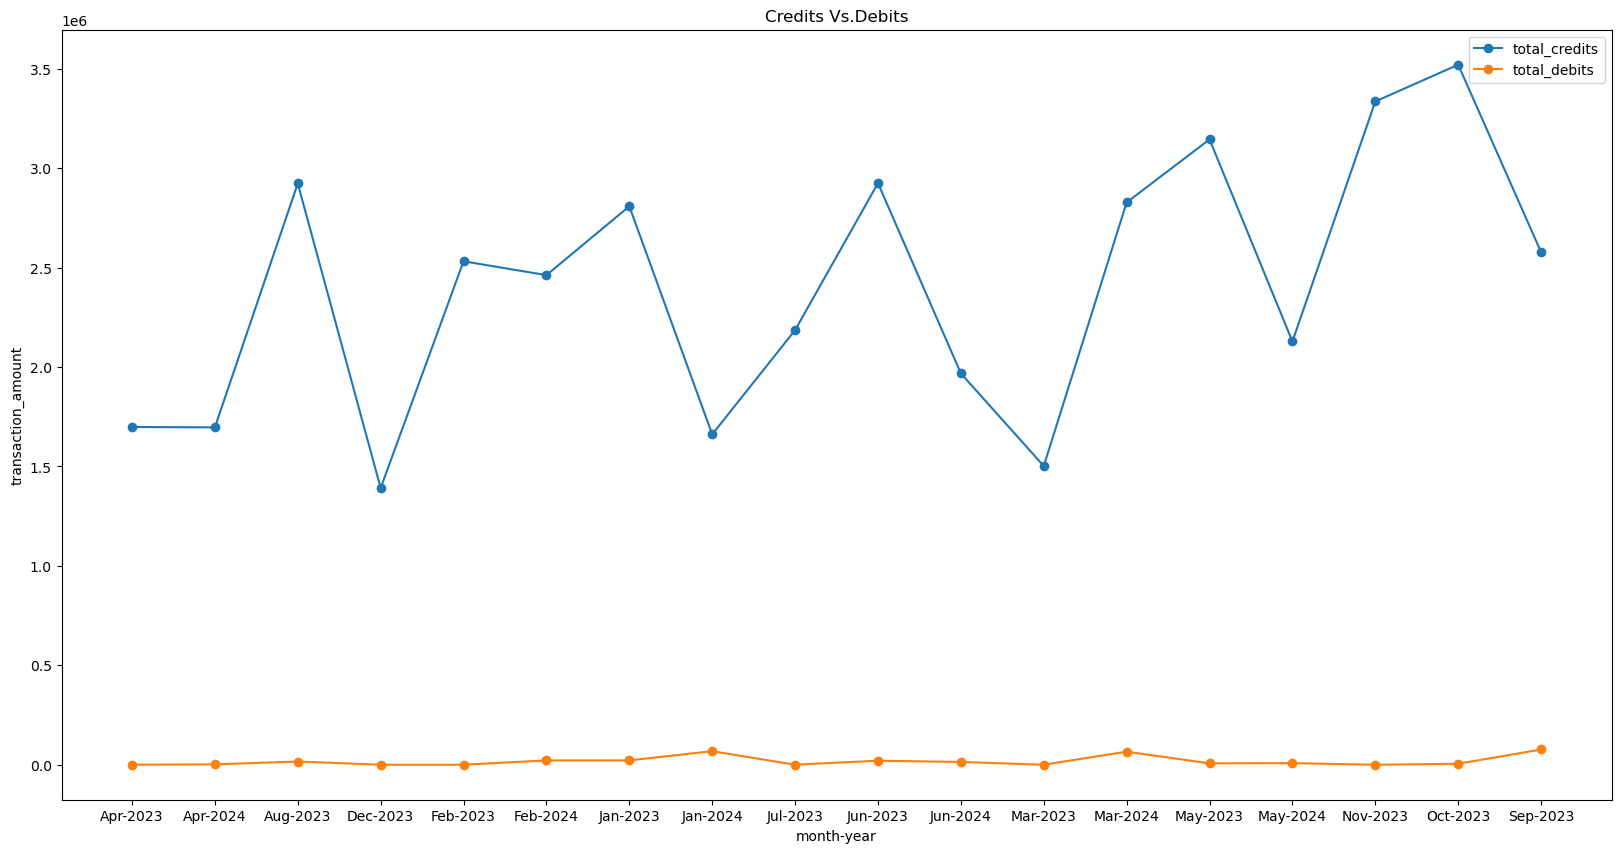

In [12]:
monthly_summary['month-year']=monthly_summary['Month']+'-'+monthly_summary['Year'].astype(str)
plt.figure(figsize=(20,10))
plt.plot(monthly_summary['month-year'],monthly_summary['total_credits'],marker='o',label='total_credits')
plt.plot(monthly_summary['month-year'],monthly_summary['total_debits'],marker='o',label='total_debits')
plt.title('Credits Vs.Debits')
plt.xlabel('month-year')
plt.ylabel('transaction_amount')
plt.legend()
plt.show

In [13]:
## Identify top and bottom performing accounts based on net inflow.
acc_summary=df.groupby('AccountID').agg(total_credits=('credits','sum'),total_debits=('debits','sum'))
acc_summary['net_flow']=acc_summary['total_credits']-acc_summary['total_debits']
top_performing_account=acc_summary.sort_values('net_flow',ascending=False).head(3)
bottom_performing_account=acc_summary.sort_values('net_flow',ascending=True).head(3)
print(top_performing_account)
print(bottom_performing_account)

           total_credits  total_debits      net_flow
AccountID                                           
ACC54589    720103.59559           0.0  720103.59559
ACC92558    645089.10225           0.0  645089.10225
ACC49422    564943.53345           0.0  564943.53345
           total_credits  total_debits      net_flow
AccountID                                           
ACC28154        0.000000   2920.562029  -2920.562029
ACC32212     1592.907285      0.000000   1592.907285
ACC52650    27316.676020   7411.898764  19904.777256


In [113]:
## Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.
df=df.sort_values(['AccountID','TransactionDate'])
df['gap_days']=df.groupby('AccountID')['TransactionDate'].diff().dt.days
df['status']=df['gap_days'].apply(lambda x:'dormant' if pd.notnull(x) and x >= 60 else 'active')
acc_status=df.groupby('AccountID')['gap_days'].max().reset_index()
acc_status['status']=acc_status['gap_days'].apply(lambda x: 'dormant' if pd.notnull(x) and x>=60 else 'active')
acc_status

,AccountID,gap_days,status
0,ACC10117,160.0,dormant
1,ACC10996,272.0,dormant
2,ACC11062,88.0,dormant
3,ACC11188,195.0,dormant
4,ACC11285,410.0,dormant
...,...,...,...
188,ACC97225,236.0,dormant
189,ACC97411,227.0,dormant
190,ACC99117,219.0,dormant
191,ACC99409,125.0,dormant


## Task 3: Customer Profile Building 

In [15]:
# Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. 
# Do not forget to mention the rubric in the headings.
## rubric -- activity level 'high' if txns frequency > 4, 'medium' if txns frequency > 2, 'low' if txns frequency <= 2.
acc_level=df.groupby('AccountID').agg(txns_frequency=('TransactionID','count')).reset_index()
def activity(freq):
    if freq>4:
        return 'high'
    elif freq>2:
        return 'medium'
    else:
        return 'low'
acc_level['activity_level']=acc_level['txns_frequency'].apply(activity)       
acc_level

,AccountID,txns_frequency,activity_level
0,ACC10117,4,medium
1,ACC10996,5,high
2,ACC11062,2,low
3,ACC11188,4,medium
4,ACC11285,3,medium
...,...,...,...
188,ACC97225,5,high
189,ACC97411,2,low
190,ACC99117,5,high
191,ACC99409,7,high


In [73]:
## Segment customers by average balance and transaction volume.
customer_seg=df.groupby('CustomerID').agg(avg_account_balance=('AccountBalance','mean'),avg_txn_volume=('TransactionAmount','mean')).reset_index()
def value(va):
    if va['avg_account_balance'] > 80000 and va['avg_txn_volume'] > 50000 :
        return 'high value'
    elif va['avg_account_balance'] > 50000 and va['avg_txn_volume'] > 30000:
        return 'medium value'
    else:
        return 'low value'
customer_seg['cust_value']=customer_seg.apply(value,axis=1)
customer_seg    

,CustomerID,avg_account_balance,avg_txn_volume,cust_value
0,CUST1042,96595.402820,45305.042109,medium value
1,CUST1114,72673.007480,64583.043923,medium value
2,CUST1121,85215.172188,65830.727603,high value
3,CUST1189,53990.275130,77454.100180,medium value
4,CUST1223,61344.838365,65165.067470,medium value
...,...,...,...,...
179,CUST9683,70865.659807,41098.401660,medium value
180,CUST9731,80565.069528,58129.926375,high value
181,CUST9754,52320.665860,22271.221635,low value
182,CUST9843,93833.161807,63524.049955,high value


In [17]:
## Create profiles for: High-net inflow accounts
acc_flow=df.groupby('AccountID').agg(net_inflow=('TransactionAmount','sum'),txns_counts=('TransactionID','count'))
high_net_inflow_accounts=acc_flow[(acc_flow['net_inflow']>=200000)&(acc_flow['txns_counts']>4)]
high_net_inflow_accounts

,net_inflow,txns_counts
AccountID,,
ACC10996,269471.352210,5
ACC12334,328726.210720,5
ACC13357,280648.886720,5
ACC15228,288474.722111,6
ACC16241,236723.790110,5
...,...,...
ACC94242,322442.834600,7
ACC95164,298570.261110,5
ACC95774,236991.600100,5


In [18]:
## profile for High-frequency low-balance accounts.
acc_stat=df.groupby('AccountID').agg(avg_account_balance=('AccountBalance','mean'),txns_counts=('TransactionID','count'))
high_frq_low_balance_acc=acc_stat[(acc_stat['avg_account_balance']<60000)&(acc_stat['txns_counts']>4)]
high_frq_low_balance_acc

,avg_account_balance,txns_counts
AccountID,,
ACC10996,56982.152538,5
ACC12334,58469.937674,5
ACC16241,55945.625702,5
ACC26940,59696.385565,5
ACC30146,49391.925607,6
ACC46655,57869.987550,8
ACC49140,50181.177677,6
ACC50439,50199.215838,5
ACC54589,54155.282135,10


In [19]:
## create profile for Accounts with negative or near-zero balance
negative_balance_account=df[['AccountID','AccountBalance']]
negative_balance_account =negative_balance_account[negative_balance_account['AccountBalance']<0].reset_index(drop=True)
negative_balance_account

,AccountID,AccountBalance
0,ACC11285,-17751.216810
1,ACC19156,-9649.975980
2,ACC21264,-8247.315181
3,ACC24880,-5199.930807
4,ACC32890,-800.699930
5,ACC41829,-2531.437176
6,ACC42467,-30766.906970
7,ACC45521,-9207.916702
8,ACC49140,-1065.037291
9,ACC49364,-2614.910348


## Task 4: Financial Risk Identification

In [20]:
## Track accounts with frequent large withdrawals or overdrafts.
withdraw=df[df['TransactionType']=='Withdrawal']
withdraw_stat=withdraw.groupby('AccountID').agg(total_withdraw=('TransactionAmount','sum'),txns_count=('TransactionID','count'))
withdraw_stat=withdraw_stat[(withdraw_stat['total_withdraw']>150000)&(withdraw_stat['txns_count']>2)]
withdraw_stat

,total_withdraw,txns_count
AccountID,,
ACC15228,183046.66893,3
ACC19178,295423.03445,5
ACC34568,270412.89502,3
ACC39529,180310.59231,3
ACC42710,300341.69432,5
ACC45521,241761.26543,3
ACC49140,204142.28646,3
ACC49180,193745.05454,3
ACC49422,285491.85068,5


In [21]:
## Calculate balance volatility using standard deviation or coefficient of variation.
balance_volatility=df.groupby('AccountID').agg(mean_balance=('AccountBalance','mean'),std_balance=('AccountBalance','std'))
balance_volatility['cv_balance']=balance_volatility['std_balance'] / balance_volatility['mean_balance']
balance_volatility=balance_volatility.sort_values(by='cv_balance',ascending=False)
balance_volatility.head()
## as we can see the below table that coefficient of variation is high for balance so there is high volatility in balance.

,mean_balance,std_balance,cv_balance
AccountID,,,
ACC55331,54330.176256,73097.164038,1.345425
ACC74631,44700.284518,50452.054088,1.128674
ACC11285,62574.613950,70126.826097,1.120691
ACC42467,47684.159638,52980.932871,1.111080
ACC70460,33835.403142,36970.340677,1.092653


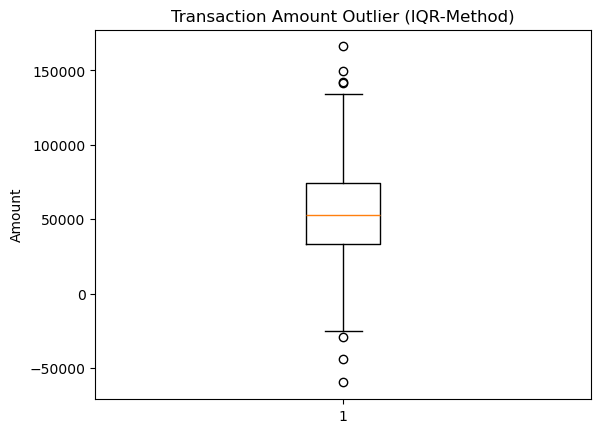

In [22]:
## Use IQR or z-score methods to detect anomalies.
## IQR (Inter Quartile Range)
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
anomalies=df[(df['TransactionAmount']<lower)|(df['TransactionAmount']>upper)].reset_index(drop=True)   
plt.boxplot(df['TransactionAmount'])
plt.title('Transaction Amount Outlier (IQR-Method)')
plt.ylabel('Amount')
plt.show()

In [23]:
## Highlight customers with irregular or suspicious transaction behavior.
suspicious_txns=df.groupby('CustomerID').agg(total_txns_amount=('TransactionAmount','sum'),txns_count=('TransactionID','count')).reset_index()
suspicious_txns['flag']=suspicious_txns.apply(lambda x: 'suspicious' if (x['total_txns_amount']>300000) and (x['txns_count']>5) else 'normal',axis=1)
suspicious_txns

,CustomerID,total_txns_amount,txns_count,flag
0,CUST1042,226525.210545,5,normal
1,CUST1114,193749.131770,3,normal
2,CUST1121,394984.365620,6,suspicious
3,CUST1189,387270.500900,5,normal
4,CUST1223,130330.134940,2,normal
...,...,...,...,...
179,CUST9683,123295.204979,3,normal
180,CUST9731,348779.558252,6,suspicious
181,CUST9754,44542.443270,2,normal
182,CUST9843,381144.299730,6,suspicious


## Task 5: Visualisation (10 Marks)

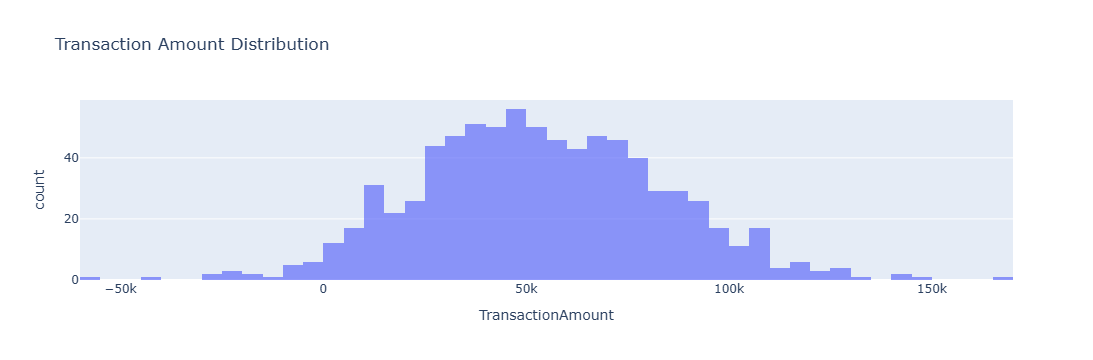

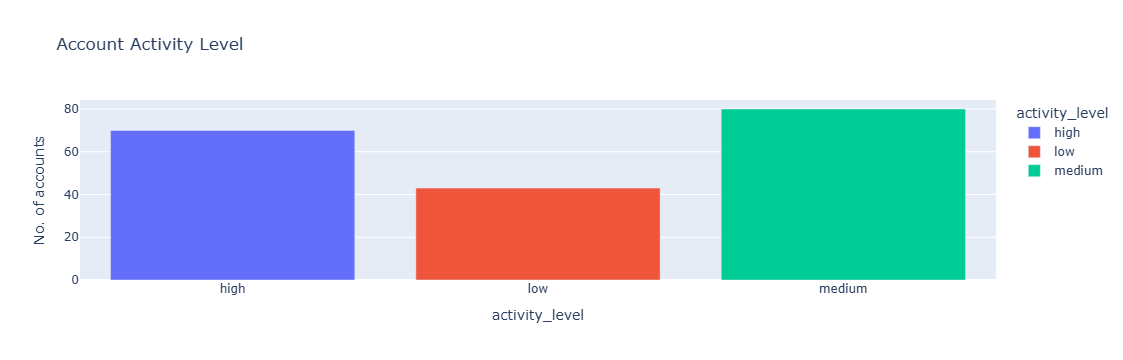

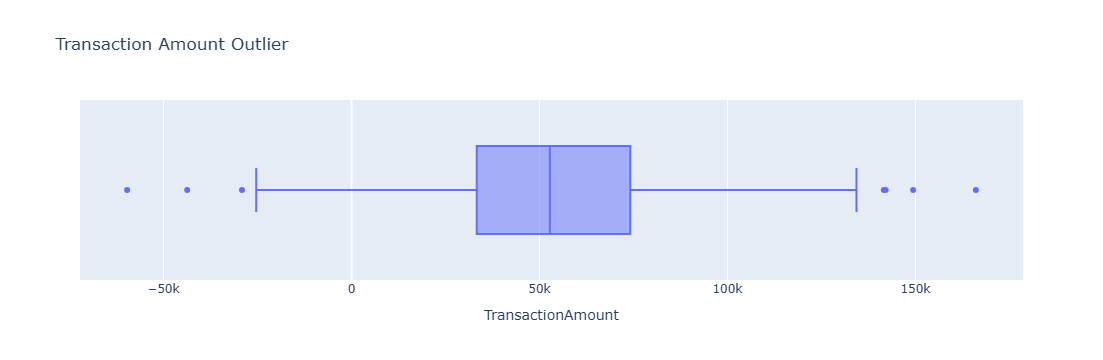

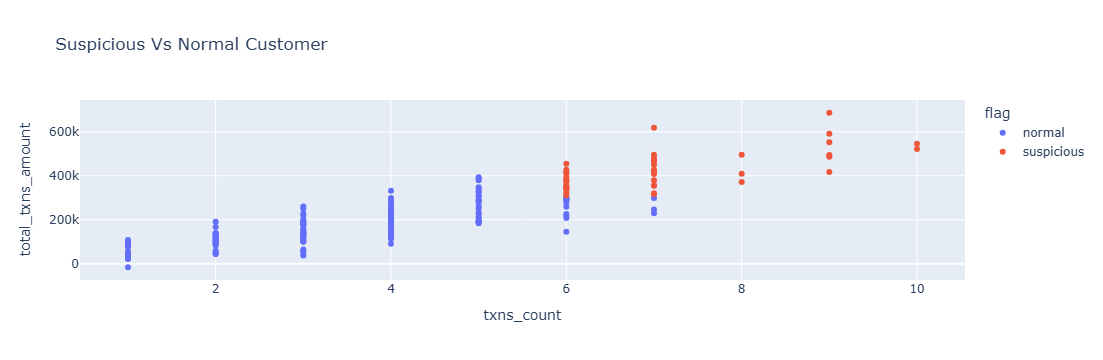

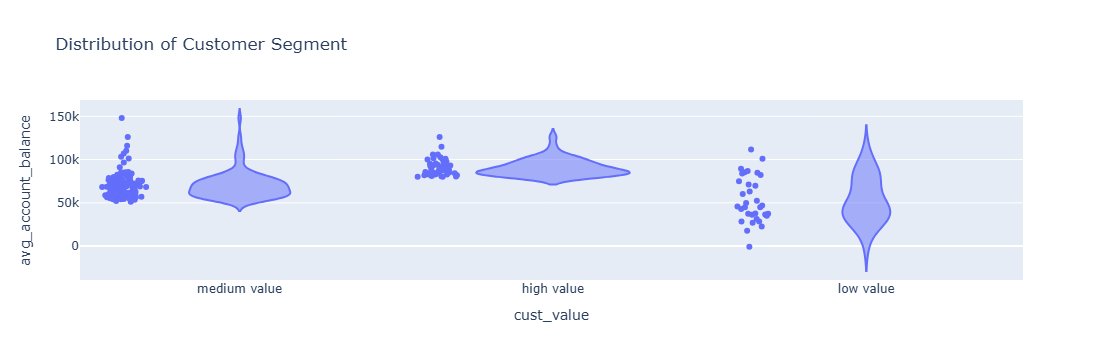

In [42]:
## Conduct extensive exploratory data analysis with attractive visualizations for your findings.
import plotly.express as px
# Transaction Amount distribution(Histogram)
fig=px.histogram(df,x='TransactionAmount',nbins=50,title='Transaction Amount Distribution',opacity=0.7)
fig.show()
# Account activity levels(Bar Graph)
account_level=acc_level.groupby('activity_level')['AccountID'].count().reset_index()
fig=px.bar(account_level,x='activity_level',y='AccountID',labels={'AccountID':'No. of accounts'},color='activity_level',title='Account Activity Level')
fig.show()
# Boxplot to detect outlier(Boxplot)
fig=px.box(df,x='TransactionAmount',title='Transaction Amount Outlier')
fig.show()
# Highlight suspicious transaction.(Scatter Plot)
fig=px.scatter(suspicious_txns,x='txns_count',y='total_txns_amount',color='flag',hover_name='CustomerID',title='Suspicious Vs Normal Customer')
fig.show()
# Distribution of Customer Segment.(Violin Chart)
fig=px.violin(customer_seg,x='cust_value',y='avg_account_balance',points='all',title='Distribution of Customer Segment')
fig.show()

## Task 6: Hypothesis Testing

In [109]:
## Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.
# Null Hypothesis(H0) : High volume accounts do not have higher balances than low volume accounts.
# Alternative Hypothesis(H1) : High volume accounts have higher balances than low volume accounts.
txns_freq = df.groupby('AccountID').agg(txns_count=('TransactionID','count'),avg_balance=('AccountBalance','mean'))
parameter = txns_freq['txns_count'].median()
high_vol = txns_freq[txns_freq['txns_count']>=parameter].reset_index()
low_vol = txns_freq[txns_freq['txns_count']<parameter].reset_index()
from scipy.stats import ttest_ind
t_stat,p_value = ttest_ind(high_vol['avg_balance'],low_vol['avg_balance'],equal_var=False,alternative='greater')
print('T-stats:',t_stat)
print('P-value:',p_value)
if p_value<0.05:
    print('Reject H0 : High volume accounts have significantly higher balances than low volume account.')
else:
    print('Pass H0 : High volume accounts do not have higher balances than low volume accounts.')

T-stats: -0.8599957100615481
P-value: 0.8041763291368582
Pass H0 : High volume accounts do not have higher balances than low volume accounts.


In [108]:
## Conduct hypothesis testing based on segmentation.(Using ANOVA test)
# Null Hypothesis(H0) : All three segments have same average balance.
# Alternative Hypothesis(H1) : Atleast one segment has a different average balance.
acc_info=df.groupby('AccountID').agg(avg_bal=('AccountBalance','mean')).reset_index()
def seg(func):
    if func['avg_bal'] > 80000  :
        return 'high value'
    elif func['avg_bal'] > 60000 :
        return 'medium value'
    else:
        return 'low value'
acc_info['acc_segment']=acc_info.apply(seg,axis=1)    
from scipy.stats import f_oneway
high=acc_info[acc_info['acc_segment']=='high value']['avg_bal']
medium=acc_info[acc_info['acc_segment']=='medium value']['avg_bal']
low=acc_info[acc_info['acc_segment']=='low value']['avg_bal']
f_stat,p_value=f_oneway(high,medium,low)
print('F statistic:',f_stat)
print('P value:',p_value)
if p_value<0.05:
    print('Reject H0 : Atleast one segment has a different average balance.')
else:
    print('Pass H0 : All three segments have same average balance.')

F statistic: 368.33170191991167
P value: 4.20727546526539e-66
Reject H0 : Atleast one segment has a different average balance.
